# 04 - Optimisation du seuil métier et des hyperparamètres

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import roc_auc_score, confusion_matrix
import warnings
import re
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)  # masque les logs verbeux
warnings.filterwarnings('ignore')

/home/zile/workspace/projet6/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Chargement des données

In [2]:
df = pd.read_csv('../data/processed/dataset_final.csv')
X = df.drop(columns=['TARGET'])
y = df['TARGET']

# Nettoyage des noms de colonnes (requis par LightGBM)
X.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in X.columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Réentraînement LightGBM sur le train complet
model = LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1, verbosity=-1)
model.fit(X_train, y_train)

# Probabilités de défaut sur le test
y_prob = model.predict_proba(X_test)[:, 1]

print('Modèle entraîné')
print(f'AUC test : {roc_auc_score(y_test, y_prob):.4f}')

Modèle entraîné
AUC test : 0.7741


**Analyse :** Le chargement crée deux sets strictement identiques en distribution (8.07% de défauts chacun grâce à `stratify=y`). Le modèle de base (n_estimators=100, paramètres par défaut) sert de référence avant tuning — AUC 0.7741.

## 2. Optimisation des hyperparamètres avec Optuna

GridSearchCV teste toutes les combinaisons. **Optuna** utilise un algorithme bayésien — il apprend des essais précédents pour orienter la recherche vers les zones prometteuses.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    """Fonction que Optuna va maximiser — retourne l'AUC moyenne en CV."""
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 300),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'      : trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'class_weight'    : 'balanced',
        'random_state'    : 42,
        'n_jobs'          : -1,
        'verbosity'       : -1,
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    return scores.mean()

# Lancement de l'optimisation
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nMeilleur AUC CV : {study.best_value:.4f}')
print(f'Meilleurs paramètres : {study.best_params}')

Best trial: 41. Best value: 0.770195: 100%|██████████| 50/50 [11:19<00:00, 13.59s/it]


Meilleur AUC CV : 0.7702
Meilleurs paramètres : {'n_estimators': 289, 'max_depth': 7, 'learning_rate': 0.04983328699681436, 'num_leaves': 32, 'min_child_samples': 50}


**Analyse :** Meilleur AUC CV : 0.7702 avec n_estimators=289, max_depth=7, learning_rate=0.050, num_leaves=32, min_child_samples=50. On entraîne maintenant le modèle final avec ces paramètres.

## 3. Entraînement du modèle final

On entraîne LightGBM avec les meilleurs hyperparamètres trouvés par Optuna.

In [4]:
best_params = study.best_params
best_params.update({'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1, 'verbosity': -1})

model_final = LGBMClassifier(**best_params)
model_final.fit(X_train, y_train)

y_prob = model_final.predict_proba(X_test)[:, 1]

print(f'AUC test (modèle tuné) : {roc_auc_score(y_test, y_prob):.4f}')

AUC test (modèle tuné) : 0.7759


**Analyse :** AUC test 0.7759 — légère amélioration vs base (+0.002). Les hyperparamètres retenus (max_depth=7, num_leaves=32) évitent un arbre trop profond qui overfit.

## 4. Optimisation du seuil métier

Maintenant qu'on a le meilleur modèle, on cherche le seuil qui minimise le coût métier : **FN coûte 10x plus qu'un FP**.

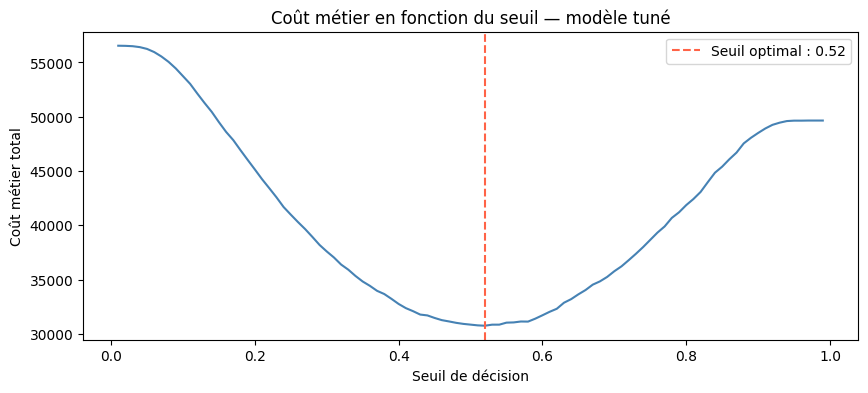

Seuil 0.50 → Sensibilité : 0.6844 | Spécificité : 0.7313 | Coût : 30863
Seuil 0.52 → Sensibilité : 0.6592 | Spécificité : 0.7552 | Coût : 30762


In [5]:
COUT_FN = 10
COUT_FP = 1

seuils = np.arange(0.01, 1.0, 0.01)
couts = []

for seuil in seuils:
    y_pred = (y_prob >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    couts.append(fn * COUT_FN + fp * COUT_FP)

seuil_optimal = seuils[np.argmin(couts)]

plt.figure(figsize=(10, 4))
plt.plot(seuils, couts, color='steelblue')
plt.axvline(seuil_optimal, color='tomato', linestyle='--', label=f'Seuil optimal : {seuil_optimal:.2f}')
plt.xlabel('Seuil de décision')
plt.ylabel('Coût métier total')
plt.title('Coût métier en fonction du seuil — modèle tuné')
plt.legend()
plt.show()

# Comparaison 0.5 vs seuil optimal
for seuil in [0.5, seuil_optimal]:
    y_pred = (y_prob >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    cout = fn * COUT_FN + fp * COUT_FP
    print(f'Seuil {seuil:.2f} → Sensibilité : {sens:.4f} | Spécificité : {spec:.4f} | Coût : {cout}')

## 5. Logging MLflow — modèle final

On log dans MLflow les meilleurs hyperparamètres, le seuil optimal, les métriques finales et le modèle lui-même dans le **Model Registry**.

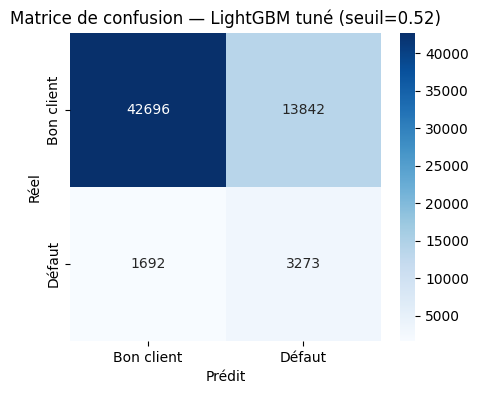

2026/03/21 10:29:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/21 10:29:36 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


AUC test    : 0.7759
Sensibilité : 0.6592
Spécificité : 0.7552
Coût métier : 30762
Seuil       : 0.52

Modèle loggé dans le Model Registry : scoring-credit-lgbm


Registered model 'scoring-credit-lgbm' already exists. Creating a new version of this model...
Created version '2' of model 'scoring-credit-lgbm'.


In [ ]:
mlflow.set_tracking_uri('../mlruns')
mlflow.set_experiment('scoring-credit')

# Calcul des métriques finales avec le seuil optimal
y_pred_final = (y_prob >= seuil_optimal).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
auc_final      = roc_auc_score(y_test, y_prob)
sensibilite    = tp / (tp + fn)
specificite    = tn / (tn + fp)
cout_final     = fn * COUT_FN + fp * COUT_FP

with mlflow.start_run(run_name='lightgbm_optuna_final'):

    # Log des hyperparamètres Optuna
    for param, value in study.best_params.items():
        mlflow.log_param(param, value)

    # Log du seuil optimal et des métriques
    mlflow.log_param('seuil_optimal', seuil_optimal)
    mlflow.log_metric('auc_test',      auc_final)
    mlflow.log_metric('sensibilite',   sensibilite)
    mlflow.log_metric('specificite',   specificite)
    mlflow.log_metric('cout_metier',   cout_final)

    # Matrice de confusion
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Bon client', 'Défaut'],
                yticklabels=['Bon client', 'Défaut'])
    ax.set_xlabel('Prédit') ; ax.set_ylabel('Réel')
    ax.set_title(f'Matrice de confusion — LightGBM tuné (seuil={seuil_optimal:.2f})')
    mlflow.log_figure(fig, 'confusion_matrix.png')
    plt.show()

    # Sauvegarde du modèle dans le Model Registry
    mlflow.lightgbm.log_model(model_final, name='model', registered_model_name='scoring-credit-lgbm')

    print(f'AUC test    : {auc_final:.4f}')
    print(f'Sensibilité : {sensibilite:.4f}')
    print(f'Spécificité : {specificite:.4f}')
    print(f'Coût métier : {cout_final}')
    print(f'Seuil       : {seuil_optimal:.2f}')
    print('\nModèle loggé dans le Model Registry : scoring-credit-lgbm')

**Analyse :**

- **Optuna** a légèrement amélioré l'AUC : 0.7759 vs 0.7741 avec les paramètres par défaut (+0.002).
- **Seuil optimal = 0.52** — légèrement au-dessus de 0.5, cohérent avec un modèle bien calibré par `class_weight='balanced'`.
- À seuil 0.52 vs 0.50 : sensibilité baisse de 0.684 → 0.659, spécificité monte de 0.731 → 0.755, coût réduit de 30 863 → 30 762 (-101).
- Le modèle est enregistré dans le **Model Registry** (`scoring-credit-lgbm`).

**Résultat final :** LightGBM tuné, seuil 0.52, AUC=0.776, Sensibilité=0.659, Spécificité=0.755, Coût métier=30 762.

In [ ]:
from mlflow.tracking import MlflowClient
client = MlflowClient(tracking_uri='../mlruns')
for mv in client.search_model_versions("name='scoring-credit-lgbm'"):
    print(mv.version, mv.run_id, mv.source)

2 22802fa52e834e3ebf1076791f9dbe8a models:/m-64d01741e33b44018041e702efd08c9b
1 51570bf35d7d4512b6c8c0686d674b74 models:/m-c71be821fd9f459095b26294bcb397c6


**Analyse :** Le modèle version 2 est celui produit par Optuna. On récupère son `run_id` pour construire l'URI de serving.

## 6. MLflow Serving

Une fois le modèle enregistré dans le Model Registry, MLflow permet de l'exposer comme une **API REST** en une seule commande. N'importe quelle application peut alors envoyer des données et recevoir une prédiction — sans avoir besoin du code Python du modèle.

### 6.1 Lancer le serveur

Commande à exécuter dans un terminal (venv activé, depuis la racine du projet) :

```bash
mlflow models serve \
  -m "runs:/22802fa52e834e3ebf1076791f9dbe8a/model" \
  --port 5001 \
  --no-conda
```

Le serveur écoute sur `http://127.0.0.1:5001`. L'endpoint de prédiction est `/invocations`.

### 6.2 Préparer la requête

Le format attendu par MLflow est `dataframe_split` : un dictionnaire avec les noms de colonnes et les valeurs. On prend un client du test set comme exemple.

In [9]:
import json

# On prend la première ligne du test set comme exemple
sample = X_test.iloc[[0]]

payload = {
    "dataframe_split": {
        "columns": sample.columns.tolist(),
        "data": sample.values.tolist()
    }
}

### 6.3 Envoyer la requête et interpréter la réponse

In [10]:
import requests

response = requests.post(
    'http://127.0.0.1:5001/invocations',
    headers={'Content-Type': 'application/json'},
    data=json.dumps(payload)
)

print('Status :', response.status_code)
print('Réponse :', response.json())

Status : 200
Réponse : {'predictions': [0]}


**Analyse :** Status 200 — la requête a réussi. Le modèle renvoie `0` (bon client) pour ce client. Le serving MLflow expose le modèle exactement comme il ferait une prédiction locale, mais via HTTP — ce qui permet de l'intégrer dans n'importe quelle application.